# Задание 3. 

Поработайте с датасетом House Sales in King County. Обратите внимание, что не все признаки в датасете полезны. Целевая переменная - очевидно, price. 

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [53]:

data = pd.read_csv('/Users/katyamazurina/Desktop/2 sem/ML/kc_house_data.csv')
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [55]:
data[['price', 'bathrooms', 'floors', 'lat', 'long']] = data[['price', 'bathrooms', 'floors', 'lat', 'long']].astype(int)
data['date'] = data['date'].str.replace(r'[a-zA-Zа-яА-Я]', '', regex=True)
data.drop('id', axis=1, inplace=True) 

<Axes: >

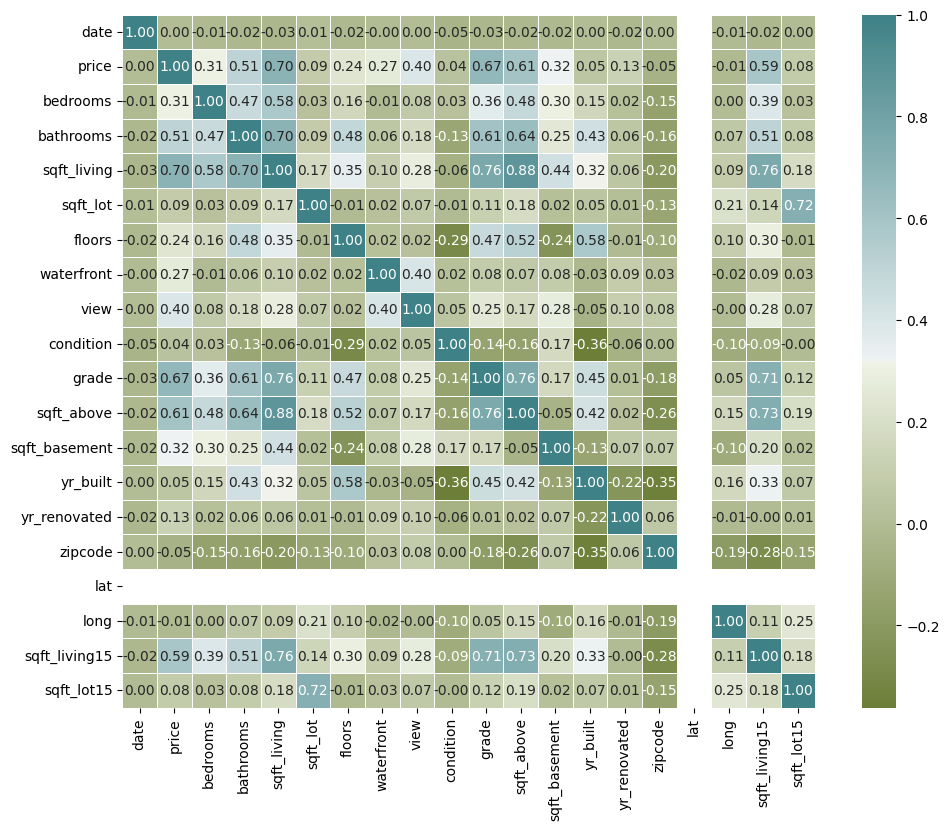

In [56]:
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [57]:
data.drop(['sqft_lot', 'condition', 'yr_built', 'zipcode', 'date', 'sqft_lot15'], axis=1, inplace=True)

In [60]:
X = data.copy().drop('price', axis=1) 
y = data['price']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

In [61]:
r2_score(ytrain,ypred_train), r2_score(ytest,ypred_test)

(0.6068720657206206, 0.606488318385093)

In [62]:
#L1-регуляризация
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2 = regressor2.predict(Xtest)

print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
print(regressor2.coef_,'\n')

Scores: 0.6065017516142743 60694755195.688255
[-30459.84413661  18863.29544568 220682.54902037 -26415.11069895
  50740.82606918  46765.73366022 113569.71212754 -66754.09002599
 -28555.0799362   25162.62349483      0.         -21652.08454079
  13744.3750552 ] 



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.973e+13, tolerance: 2.246e+11
  model = cd_fast.enet_coordinate_descent(


In [63]:
#разные значения параметра регуляризации а
for a in np.arange(0.1,100.1,25):
    regressor2 = Lasso(alpha=a)
    regressor2.fit(Xtrain, ytrain)

    ypred2 = regressor2.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
    print(regressor2.coef_,'\n')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.961e+13, tolerance: 2.246e+11
  model = cd_fast.enet_coordinate_descent(


alpha=0.1
Scores: 0.6064884529119545 60696806441.113174
[-30467.83607909  18918.60877172 243663.09966381 -26450.24514357
  50748.30212996  46766.00272189 113558.14152263 -87541.85918827
 -39725.09863626  25172.84441776      0.         -21662.80478724
  13795.87513551] 



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.987e+13, tolerance: 2.246e+11
  model = cd_fast.enet_coordinate_descent(


alpha=25.1
Scores: 0.6065219613015638 60691637972.09792
[-30447.65440618  18778.92865546 185631.40611979 -26361.52179856
  50729.42318858  46765.32327323 113587.36022189 -35047.49261685
 -11517.98070681  25147.03400632      0.         -21635.73345782
  13665.82442764] 

alpha=50.1
Scores: 0.6064632076857914 60700700366.50703
[-30338.03369062  18825.50542448 146571.61461836 -26335.32914436
  50718.59644856  46763.74082855 113529.63481123      0.
   7261.90527273  25133.66321778      0.         -21609.1528091
  13775.2703728 ] 

alpha=75.1
Scores: 0.6064505945748653 60702645863.55324
[-30273.06369212  18777.79720546 146538.09347777 -26277.65564189
  50703.73374519  46762.57687197 113516.2952479       0.
   7267.3795211   25114.09716343      0.         -21582.23828331
  13764.55324192] 



In [64]:
#оптимальное значение параметра регуляризации по кросс-валидации
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 88629415996320.62, tolerance: 196982726894.80148
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 88629084020120.81, tolerance: 196982726894.80148
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 88628768789697.31, tolerance: 196982726894.80148
  model = cd_fast.enet_coord

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [65]:
lasso_cv.alpha_

0.1

In [66]:
#обучение с найденным параметром регуляризации альфа
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test))

Scores: 0.6068720657182294 0.6064884529119545


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.961e+13, tolerance: 2.246e+11
  model = cd_fast.enet_coordinate_descent(


In [67]:
#L2-регуляризация
from sklearn.linear_model import Ridge

for a in np.arange(0.1,10.1,2.5):
    regressor3 = Ridge(alpha=a)
    regressor3.fit(Xtrain, ytrain)

    ypred3 = regressor3.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred3), mean_squared_error(ytest,ypred3))
    print(regressor3.coef_)

alpha=0.1
Scores: 0.6064879451382925 60696884762.16857
[-30467.37486484  18919.42994238  76769.29093055 -26449.96825903
  50748.18947037  46765.97981136 113556.7373722   63040.10176438
  41080.15259961  25172.86708067      0.         -21662.81403851
  13797.47359055]
alpha=2.6
Scores: 0.606478612198275 60698324312.438354
[-30453.82999985  18925.98732213  76756.90358931 -26434.18129615
  50743.48548508  46765.33890143 113524.57206114  63027.61659444
  41077.83451635  25170.85241001      0.         -21660.33783237
  13824.41057032]
alpha=5.1
Scores: 0.6064692758651737 60699764386.07103
[-30440.29216684  18932.53725871  76744.52723996 -26418.40871291
  50738.78226696  46764.69760225 113492.43859872  63015.14394182
  41075.51586254  25168.83735129      0.         -21657.86094565
  13851.31043194]
alpha=7.6
Scores: 0.6064599361547811 60701204980.63072
[-30426.76136034  18939.07976496  76732.16187714 -26402.65048752
  50734.07981665  46764.05591233 113460.33693234  63002.68377446
  41073.196

In [68]:
#оптимальное a по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(0, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas, 
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e+00, 1.07189132e+00, 1.14895100e+00, 1.23155060e+00,
       1.32008840e+00, 1.41499130e+00, 1.51671689e+00, 1.62575567e+00,
       1.74263339e+00, 1.86791360e+00, 2.00220037e+00, 2.14614120e+00,
       2.30043012e+00, 2.46581108e+00, 2.64308149e+00, 2.83309610e+00,
       3.03677112e+00, 3.25508860e+00, 3.48910121e+00, 3.73993730e+00,
       4.00880633e+00, 4.29700470e+0...
       2.02550194e+05, 2.17111795e+05, 2.32720248e+05, 2.49450814e+05,
       2.67384162e+05, 2.86606762e+05, 3.07211300e+05, 3.29297126e+05,
       3.52970730e+05, 3.78346262e+05, 4.05546074e+05, 4.34701316e+05,
       4.65952567e+05, 4.99450512e+05, 5.35356668e+05, 5.73844165e+05,
       6.15098579e+05, 6.59318827e+05, 7.06718127e+05, 7.57525026e+05,
       8.11984499e+05, 8.70359136e+05, 9.32930403e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [69]:
ridge_cv.alpha_

3.2550885998350583

In [70]:
regressor3 = Lasso(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred3_train = regressor3.predict(Xtrain)
ypred3_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred3_train), r2_score(ytest,ypred3_test))

Scores: 0.6068720631869986 0.6064926953351939


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.965e+13, tolerance: 2.246e+11
  model = cd_fast.enet_coordinate_descent(
